# Gold Price Analysis (تحلیل قیمت جهانی طلا)

<div style="direction: rtl; text-align: right; font-size:18px; line-height:1.9; color:#1f4e79;">

هدف این پروژه تحلیل داده‌های قیمت جهانی طلا است که از وب‌سایت <b>Yahoo Finance</b> دریافت شده‌اند. ابتدا داده‌ها وارد محیط پایتون شده و به یک <b>DataFrame</b> تبدیل می‌شوند تا پردازش و تحلیل آن‌ها آسان‌تر شود. سپس داده‌ها از نظر مقادیر گمشده، داده‌های تکراری و سایر ناهماهنگی‌ها بررسی و پاکسازی خواهند شد. پس از آماده‌سازی داده‌ها، شاخص‌های آمار توصیفی مانند <b>میانگین، مد، میانه، واریانس و انحراف معیار</b> محاسبه می‌شوند. در ادامه، نمودارهای مختلف برای نمایش روند تغییرات قیمت طلا رسم شده و در نهایت، مقایسه‌ای بین قیمت‌ها در بازه‌های زمانی <b>قبل و بعد از ۹ اسفند</b> به‌منظور بررسی نوسانات قیمت طلا قبل و بعد از جنگ انجام خواهد شد.

</div>

## Import Libraries (وارد کردن کتابخانه‌ها)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [7]:
# !pip install yfinance

## Import Gold Price Data (دریافت داده‌های قیمت طلا)

In [29]:
gold = yf.download("GC=F", period="5y", auto_adjust=False)

gold.columns = gold.columns.get_level_values(0)

df = gold.copy()

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2021-07-28,1799.500000,1799.500000,1799.500000,1799.500000,1799.500000,209783
2021-07-29,1831.199951,1831.199951,1832.599976,1806.099976,1806.599976,30496
2021-07-30,1812.599976,1812.599976,1830.500000,1808.900024,1828.000000,3100
2021-08-02,1818.099976,1818.099976,1818.699951,1804.800049,1812.400024,1334
2021-08-03,1810.099976,1810.099976,1813.500000,1806.000000,1812.300049,3341


## Convert Data to DataFrame

In [30]:
df.style.background_gradient(cmap="Blues")

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2021-07-28 00:00:00,1799.500000,1799.500000,1799.500000,1799.500000,1799.500000,209783
2021-07-29 00:00:00,1831.199951,1831.199951,1832.599976,1806.099976,1806.599976,30496
2021-07-30 00:00:00,1812.599976,1812.599976,1830.500000,1808.900024,1828.000000,3100
2021-08-02 00:00:00,1818.099976,1818.099976,1818.699951,1804.800049,1812.400024,1334
2021-08-03 00:00:00,1810.099976,1810.099976,1813.500000,1806.000000,1812.300049,3341
2021-08-04 00:00:00,1810.500000,1810.500000,1831.300049,1806.300049,1809.300049,2860
2021-08-05 00:00:00,1805.099976,1805.099976,1813.699951,1796.000000,1810.800049,588
2021-08-06 00:00:00,1760.000000,1760.000000,1800.099976,1758.400024,1799.800049,859
2021-08-09 00:00:00,1723.400024,1723.400024,1753.800049,1692.599976,1753.500000,1621


## Data Cleaning (پاکسازی داده‌ها)

### Check Dataset Information (بررسی اطلاعات دیتاست)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1256 entries, 2021-07-28 to 2026-07-27
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  1256 non-null   float64
 1   Close      1256 non-null   float64
 2   High       1256 non-null   float64
 3   Low        1256 non-null   float64
 4   Open       1256 non-null   float64
 5   Volume     1256 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 101.0 KB


### Check Missing Values (بررسی مقادیر گمشده)

In [32]:
df.isnull().sum()

Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

### Check Duplicate Values (بررسی داده‌های تکراری)

In [33]:
df.duplicated().sum()

np.int64(0)

## Descriptive Statistics (آمار توصیفی)

### Statistical Summary (خلاصه آماری)

In [34]:
df.describe()

Price,Adj Close,Close,High,Low,Open,Volume
count,1256.000000,1256.000000,1256.000000,1256.000000,1256.000000,1256.000000
mean,2591.794422,2591.794422,2607.363058,2575.677788,2591.532566,4079.996815
std,975.389277,975.389277,987.441511,963.900984,976.979598,20844.221733
min,1623.300049,1623.300049,1623.300049,1615.099976,1620.400024,0.000000
25%,1851.275024,1851.275024,1861.300018,1844.350006,1850.175049,97.000000
50%,2035.649963,2035.649963,2045.450012,2027.899963,2035.800049,336.500000
75%,3233.999939,3233.999939,3279.549988,3223.875000,3238.700012,901.250000
max,5318.399902,5318.399902,5586.200195,5301.600098,5415.700195,209783.000000


### Arithmetic Mean (میانگین حسابی)

In [36]:
df.mean()

Price
Adj Close    2591.794422
Close        2591.794422
High         2607.363058
Low          2575.677788
Open         2591.532566
Volume       4079.996815
dtype: float64

### Median (میانه)

In [37]:
df.median()

Price
Adj Close    2035.649963
Close        2035.649963
High         2045.450012
Low          2027.899963
Open         2035.800049
Volume        336.500000
dtype: float64

### Mode (نما)

In [38]:
df.mode()

Price,Adj Close,Close,High,Low,Open,Volume
0,1788.699951,1788.699951,1667.000000,1781.000000,1794.300049,0.0
1,1795.900024,1795.900024,1768.000000,1784.000000,1794.900024,NaN
2,1815.900024,1815.900024,1791.400024,1787.900024,1795.500000,NaN
3,1918.400024,1918.400024,NaN,1867.000000,1825.000000,NaN
4,1952.400024,1952.400024,NaN,1953.000000,1925.400024,NaN
5,1955.300049,1955.300049,NaN,2319.000000,NaN,NaN


### Variance (واریانس)

In [39]:
df.var()

Price
Adj Close    9.513842e+05
Close        9.513842e+05
High         9.750407e+05
Low          9.291051e+05
Open         9.544891e+05
Volume       4.344816e+08
dtype: float64

### Standard Deviation (انحراف معیار)

In [40]:
df.std()

Price
Adj Close      975.389277
Close          975.389277
High           987.441511
Low            963.900984
Open           976.979598
Volume       20844.221733
dtype: float64

## Data Visualization (نمایش گرافیکی داده‌ها)

### Line Chart (نمودار خطی)

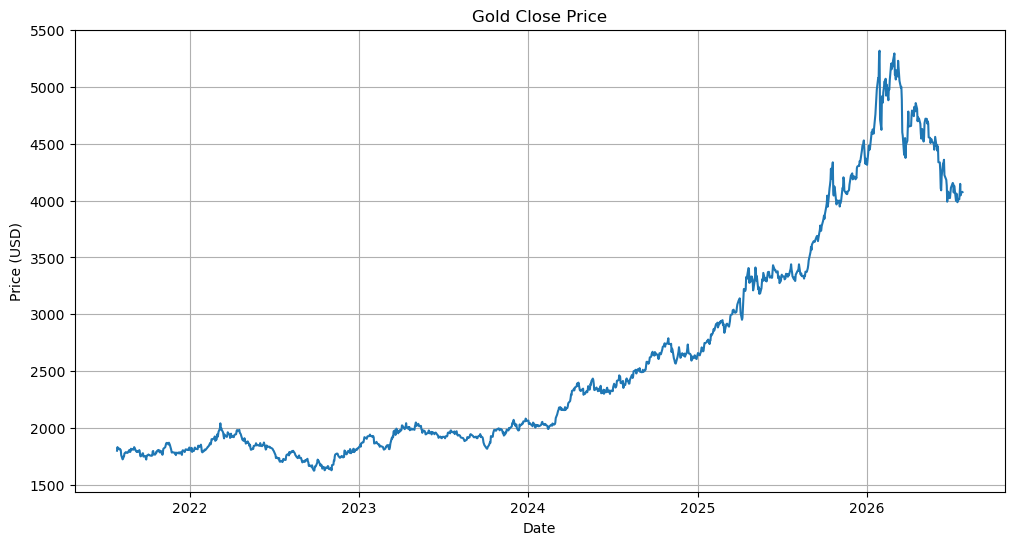

In [41]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Close"])

plt.title("Gold Close Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)

plt.show()

### Histogram (هیستوگرام)

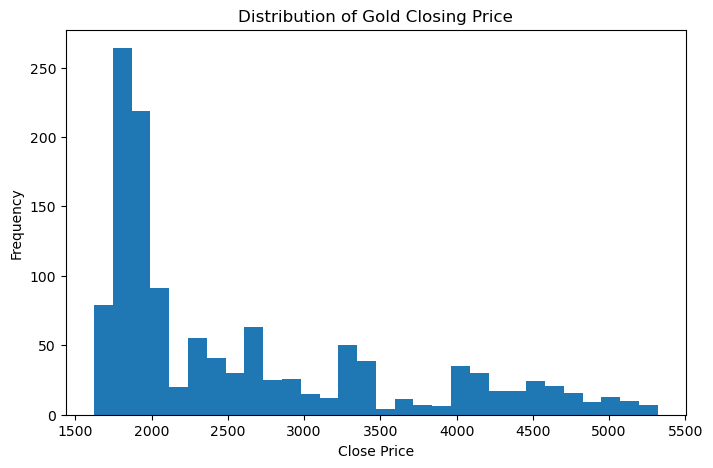

In [42]:
plt.figure(figsize=(8,5))

plt.hist(df["Close"], bins=30)

plt.title("Distribution of Gold Closing Price")
plt.xlabel("Close Price")
plt.ylabel("Frequency")

plt.show()

### Box Plot (نمودار جعبه‌ای)

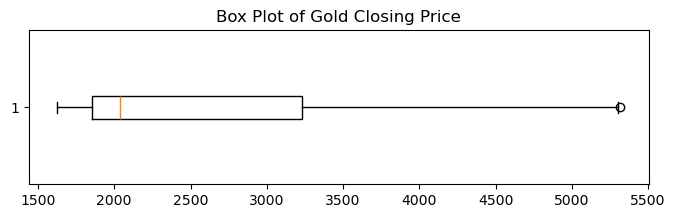

In [43]:
plt.figure(figsize=(8,2))

plt.boxplot(df["Close"])

plt.title("Box Plot of Gold Closing Price")

plt.show()

### Moving Average (میانگین متحرک)

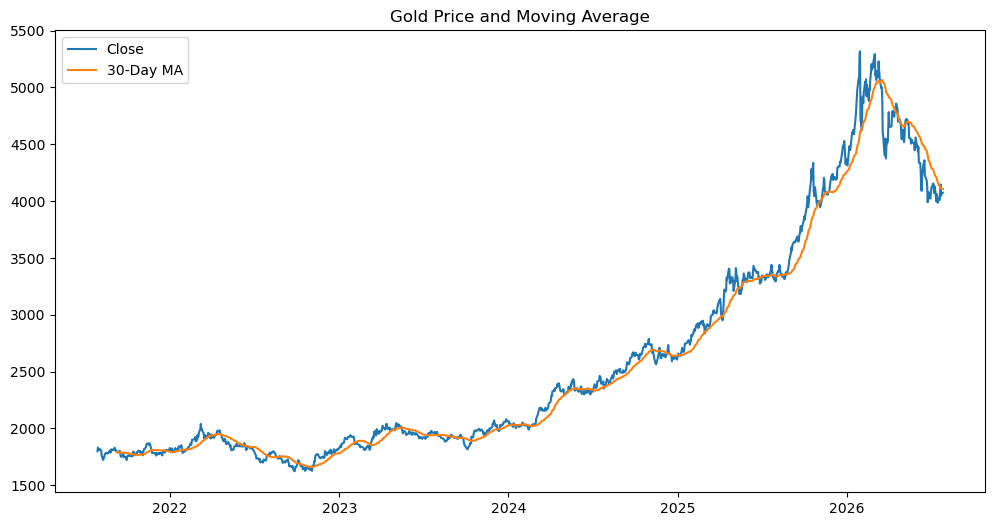

In [44]:
df["MA30"] = df["Close"].rolling(30).mean()

plt.figure(figsize=(12,6))

plt.plot(df.index, df["Close"], label="Close")
plt.plot(df.index, df["MA30"], label="30-Day MA")

plt.title("Gold Price and Moving Average")
plt.legend()

plt.show()

### Correlation Matrix (ماتریس همبستگی)

In [45]:
import seaborn as sns

sns.heatmap(df.corr(), annot=True, fmt="0.2f", cmap="coolwarm")

Price,Adj Close,Close,High,Low,Open,Volume,MA30
Price,,,,,,,
Adj Close,1.000000,1.000000,0.999538,0.999749,0.999303,-0.013569,0.993642
Close,1.000000,1.000000,0.999538,0.999749,0.999303,-0.013569,0.993642
High,0.999538,0.999538,1.000000,0.999290,0.999764,-0.014799,0.993491
Low,0.999749,0.999749,0.999290,1.000000,0.999420,-0.012448,0.993578
Open,0.999303,0.999303,0.999764,0.999420,1.000000,-0.013728,0.993635
Volume,-0.013569,-0.013569,-0.014799,-0.012448,-0.013728,1.000000,-0.009766
MA30,0.993642,0.993642,0.993491,0.993578,0.993635,-0.009766,1.000000


### Daily Price Change (تغییرات روزانه قیمت)

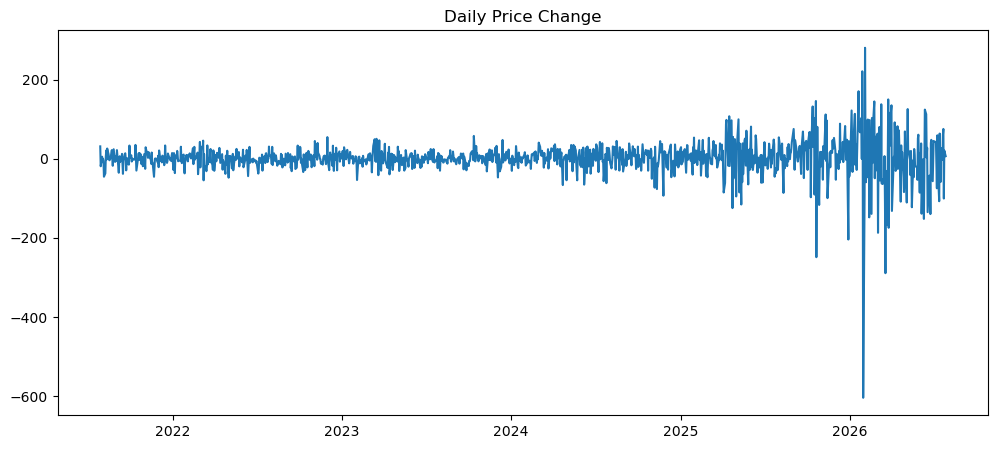

In [47]:
df["Daily Change"] = df["Close"].diff()

plt.figure(figsize=(12,5))

plt.plot(df.index, df["Daily Change"])

plt.title("Daily Price Change")

plt.show()

### Closing Price Trend (روند قیمت پایانی)

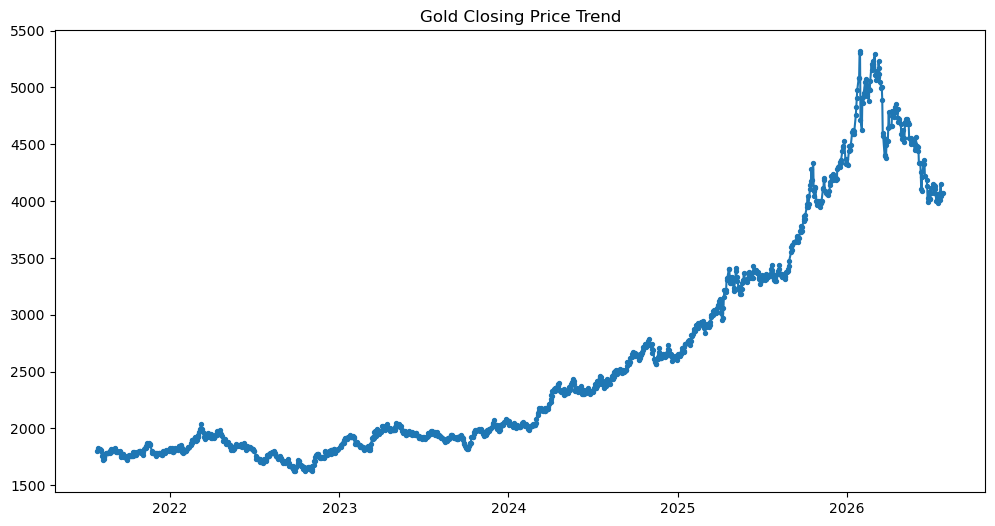

In [48]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Close"])
plt.scatter(df.index, df["Close"], s=8)

plt.title("Gold Closing Price Trend")

plt.show()

### Outlier Detection (تشخیص داده های پرت)

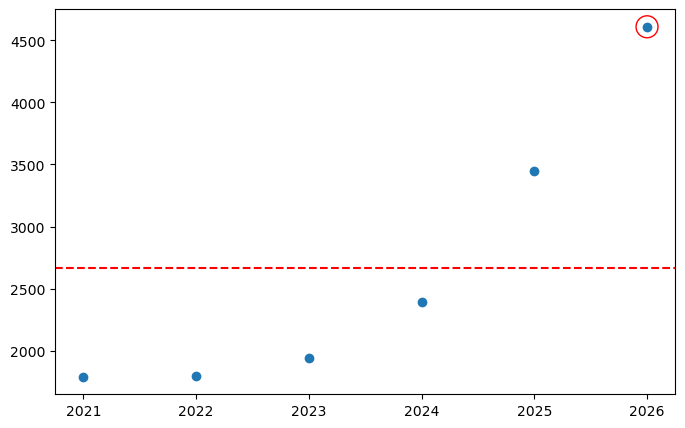

In [52]:
y = df["Close"].groupby(df.index.year).mean()

plt.figure(figsize=(8,5))

plt.scatter(y.index, y)
plt.axhline(y.mean(), ls="--", c="red")

i = abs(y - y.mean()).idxmax()
plt.scatter(i, y[i], s=250, facecolors="none", edgecolors="red")

plt.show()

## Comparison of Gold Prices Before and After February 28, 2026 (مقایسه قیمت طلا قبل و بعد از ۹ اسفند ۱۴۰۴)

### تقسیم داده ها

In [56]:
before = df[df.index < "2026-02-28"]
after = df[df.index >= "2026-02-28"]

### Statistical Comparison (مقایسه آماری)

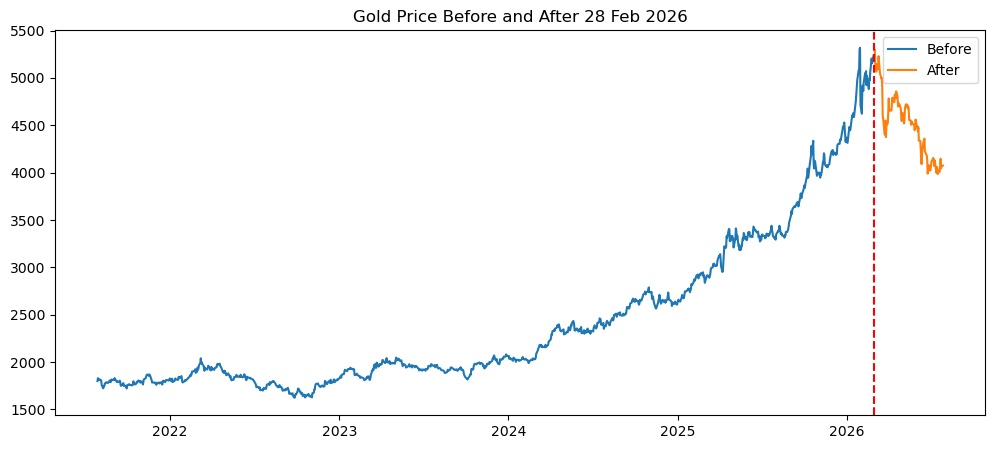

In [57]:
plt.figure(figsize=(12,5))

plt.plot(before.index, before["Close"], label="Before")
plt.plot(after.index, after["Close"], label="After")

plt.axvline(pd.Timestamp("2026-02-28"),
            color="red", linestyle="--")

plt.title("Gold Price Before and After 28 Feb 2026")
plt.legend()

plt.show()

### Zoom on the Last Two Years (بزرگ‌نمایی دو سال آخر)

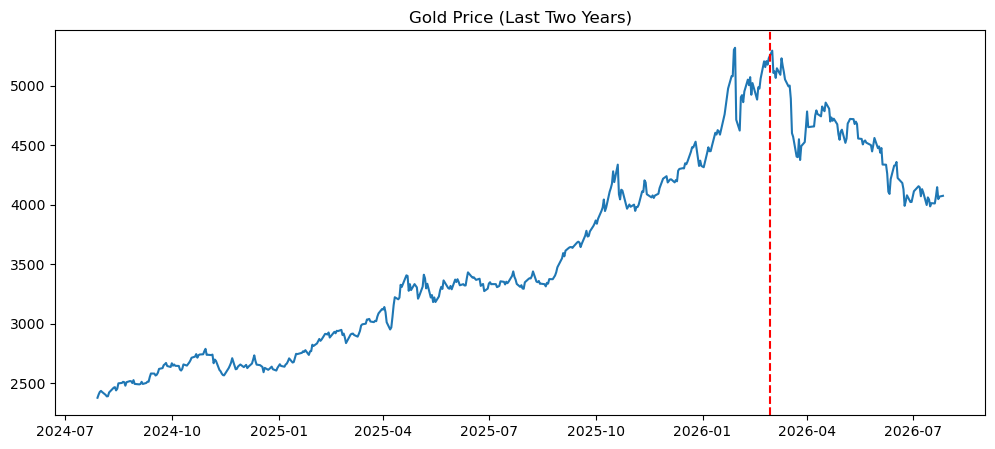

In [58]:
last2 = df[df.index >= "2024-07-27"]

plt.figure(figsize=(12,5))

plt.plot(last2.index, last2["Close"])

plt.axvline(pd.Timestamp("2026-02-28"),
            color="red", linestyle="--")

plt.title("Gold Price (Last Two Years)")
plt.show()

### Statistical Comparison Table (جدول مقایسه آماری)

In [60]:
pd.DataFrame({
    "Before": before["Close"].agg(["mean","median","min","max","std"]),
    "After": after["Close"].agg(["mean","median","min","max","std"])
}).style.background_gradient(cmap="Blues")

,Before,After
mean,2422.252162,4509.949015
median,2006.100037,4535.549805
min,1623.300049,3985.600098
max,5318.399902,5294.399902
std,819.242650,340.062158
